# DeepFace video emotion timeline v2

Este notebook é uma versão mais simples e mais fácil de ler do protótipo com DeepFace.

Objetivo:

- carregar uma lista de vídeos;
- analisar emoção facial em todos os frames com DeepFace;
- gerar uma cópia anotada do vídeo original com bounding box e label;
- salvar um JSON compacto com apenas os percentuais por emoção e os intervalos de tempo.

Nesta versão a prioridade é clareza do código. A agregação é feita diretamente em todos os frames analisados, sem a camada extra de amostragem que complicava o notebook anterior.

Saídas esperadas por vídeo:

- `outputs/emotion_timelines_v2/<video>.emotions.v2.json`
- `outputs/annotated_videos_v2/<video>.annotated.v2.mp4`

Observação importante: isto continua sendo um protótipo exploratório. O resultado mostra expressão facial aparente, não estado mental real.


## 1) Instalação do ambiente

Esta célula instala o mínimo necessário para rodar o protótipo com DeepFace.

Pontos práticos:

- rode esta célula uma vez por ambiente;
- em alguns casos o Jupyter pode pedir restart do kernel depois da instalação;
- na primeira execução real o DeepFace pode baixar arquivos do modelo automaticamente.


In [1]:
# Rode esta celula uma vez por ambiente.
%pip install -q deepface tf-keras       

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Imports e checagem do runtime

Esta célula importa bibliotecas de vídeo, dados e visualização.

Ela também tenta importar o DeepFace de forma explícita e já mostra no final se o pacote foi encontrado. Se esta célula falhar, não vale seguir adiante: primeiro ajuste o ambiente.


In [2]:
import json
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import JSON, Markdown, display

try:
    from deepface import DeepFace
except Exception as exc:
    DeepFace = None
    DEEPFACE_IMPORT_ERROR = exc
else:
    DEEPFACE_IMPORT_ERROR = None

print('OpenCV:', cv2.__version__)
if DeepFace is None:
    print('DeepFace nao importado:', DEEPFACE_IMPORT_ERROR)
else:
    print('DeepFace importado com sucesso.')



OpenCV: 4.13.0
DeepFace importado com sucesso.


## 3) Configuração do protótipo

Esta célula concentra tudo que normalmente muda entre execuções:

- lista de vídeos de entrada;
- diretórios de saída;
- mapeamento dos labels;
- threshold mínimo para aceitar uma emoção;
- duração mínima de um segmento;
- parâmetros visuais do overlay.

Nesta versão o threshold padrão foi reduzido para `0.30`. Isso é intencional: a ideia é deixar o protótipo mais sensível para capturar mais mudanças de emoção. Se o resultado ficar ruidoso demais, aumente esse valor.


In [ ]:
LABEL_MAP = {
    'angry': 'anger_expression',
    'disgust': 'disgust_expression',
    'fear': 'fear_expression',
    'happy': 'joy_expression',
    'neutral': 'neutral_expression',
    'sad': 'sad_expression',
    'surprise': 'surprise_expression',
}

VIDEO_PATHS = [
    'data/video/domestic_abuse1.mp4',
    'data/video/domestic_abuse2.mp4',
    'data/video/sad_woman1.mp4',
    'data/video/sad_woman2.mp4',
]

OUTPUT_JSON_DIR = Path('outputs/emotion_timelines_v2')
OUTPUT_VIDEO_DIR = Path('outputs/annotated_videos_v2')

MIN_CONFIDENCE = 0.30
MIN_SEGMENT_DURATION_SECONDS = 0.20

DETECTOR_BACKEND = 'opencv'
ENFORCE_DETECTION = False
ALIGN = True
SILENT = True

BOX_THICKNESS = 6
FONT_SCALE = 2
TEXT_THICKNESS = 6
TEXT_PADDING = 12
TEXT_MARGIN = 22

UNCERTAIN_LABEL = 'uncertain'
UNCERTAIN_COLOR = (0, 255, 255)
TEXT_COLOR = (255, 255, 255)

EMOTION_COLORS = {
    'anger_expression': (0, 0, 255),
    'disgust_expression': (0, 140, 255),
    'fear_expression': (255, 0, 255),
    'joy_expression': (0, 255, 0),
    'neutral_expression': (255, 255, 0),
    'sad_expression': (255, 0, 0),
    'surprise_expression': (255, 255, 255),
}

display(Markdown('\n'.join([
    '### Configura??o atual',
    f'- V?deos configurados: `{len(VIDEO_PATHS)}`',
    f'- JSON de sa?da: `{OUTPUT_JSON_DIR}`',
    f'- V?deos anotados: `{OUTPUT_VIDEO_DIR}`',
    f'- Threshold m?nimo: `{MIN_CONFIDENCE:.2f}`',
    f'- Dura??o m?nima do segmento: `{MIN_SEGMENT_DURATION_SECONDS:.2f}s`',
    f'- Detector backend: `{DETECTOR_BACKEND}`',
])))
        

## 4) Carregamento do modelo DeepFace

Aqui o notebook apenas valida se o DeepFace está disponível e força a inicialização do modelo de emoção antes do processamento em lote.

A vantagem é simples: se houver problema de instalação, compatibilidade ou download do modelo, ele aparece agora, antes de processar vários vídeos.


In [ ]:
if 'DeepFace' not in globals():
    raise NameError('Execute primeiro a c?lula de imports/runtime.')

if DeepFace is None:
    raise ImportError(
        'DeepFace n?o est? dispon?vel neste kernel. Rode a c?lula de instala??o e reinicie o kernel se necess?rio.'
    ) from DEEPFACE_IMPORT_ERROR

try:
    DEEPFACE_EMOTION_MODEL = DeepFace.build_model('Emotion', task='facial_attribute')
    print('Modelo de emo??o do DeepFace pronto.')
except Exception as exc:
    raise RuntimeError(
        'Falha ao inicializar o modelo de emo??o do DeepFace. Verifique a instala??o, a compatibilidade e o primeiro download gerenciado.'
    ) from exc


## 5) Funções auxiliares mínimas

Esta é a célula principal de apoio do notebook. Ela foi mantida propositalmente curta e com poucas funções.

O que existe aqui:

1. normalização da confiança retornada pelo DeepFace;
2. escolha da maior face quando houver mais de uma;
3. análise de um frame;
4. desenho do bounding box e da label no frame;
5. consolidação dos labels frame a frame em segmentos temporais e percentuais.

A agregação foi simplificada: um segmento é uma sequência contínua de frames com o mesmo label aceito pelo threshold. Se a emoção muda, a confiança cai abaixo do limiar, ou a face some, o segmento é encerrado.


In [ ]:
def normalize_score(raw_score):
    if raw_score is None:
        return None
    score = float(raw_score)
    if score > 1.0:
        score = score / 100.0
    return max(0.0, min(1.0, score))


def select_largest_face(analysis_result):
    if isinstance(analysis_result, dict):
        faces = [analysis_result]
    elif isinstance(analysis_result, list):
        faces = [item for item in analysis_result if isinstance(item, dict)]
    else:
        faces = []

    valid_faces = []
    for face in faces:
        region = face.get('region') or {}
        w = int(region.get('w') or 0)
        h = int(region.get('h') or 0)
        if w > 0 and h > 0:
            valid_faces.append(face)

    if not valid_faces:
        return None, 0

    largest_face = max(
        valid_faces,
        key=lambda face: int((face.get('region') or {}).get('w') or 0) * int((face.get('region') or {}).get('h') or 0),
    )
    return largest_face, len(valid_faces)


def analyze_frame(frame_bgr):
    analysis_result = DeepFace.analyze(
        img_path=frame_bgr,
        actions=['emotion'],
        detector_backend=DETECTOR_BACKEND,
        enforce_detection=ENFORCE_DETECTION,
        align=ALIGN,
        silent=SILENT,
    )

    face, face_count = select_largest_face(analysis_result)
    if face is None:
        return None

    raw_label = str(face.get('dominant_emotion') or '').lower().strip()
    if raw_label not in LABEL_MAP:
        return None

    emotion_scores = face.get('emotion') or {}
    confidence = normalize_score(emotion_scores.get(raw_label))
    region = face.get('region') or {}

    return {
        'label': LABEL_MAP[raw_label],
        'confidence': confidence,
        'face_count': face_count,
        'x': int(region.get('x') or 0),
        'y': int(region.get('y') or 0),
        'w': int(region.get('w') or 0),
        'h': int(region.get('h') or 0),
    }


def draw_annotation(frame_bgr, analysis):
    shown_label = analysis['label']
    color = EMOTION_COLORS.get(shown_label, (180, 180, 180))

    if (analysis.get('confidence') or 0.0) < MIN_CONFIDENCE:
        shown_label = UNCERTAIN_LABEL
        color = UNCERTAIN_COLOR

    x, y, w, h = analysis['x'], analysis['y'], analysis['w'], analysis['h']
    cv2.rectangle(frame_bgr, (x, y), (x + w, y + h), color, BOX_THICKNESS)

    text = f"{shown_label}: {(analysis.get('confidence') or 0.0):.2f}"
    (text_width, text_height), baseline = cv2.getTextSize(
        text,
        cv2.FONT_HERSHEY_SIMPLEX,
        FONT_SCALE,
        TEXT_THICKNESS,
    )

    text_x = x
    text_y = max(text_height + TEXT_PADDING, y - TEXT_MARGIN)

    cv2.rectangle(
        frame_bgr,
        (text_x - TEXT_PADDING, text_y - text_height - TEXT_PADDING),
        (text_x + text_width + TEXT_PADDING, text_y + baseline + TEXT_PADDING),
        color,
        -1,
    )
    cv2.putText(
        frame_bgr,
        text,
        (text_x, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        FONT_SCALE,
        TEXT_COLOR,
        TEXT_THICKNESS,
        cv2.LINE_AA,
    )

    accepted_label = analysis['label'] if shown_label != UNCERTAIN_LABEL else None
    return frame_bgr, shown_label, accepted_label


def build_segments_and_percentages(frame_labels, fps):
    if not frame_labels or fps <= 0:
        return [], {}

    segments = []
    current_label = None
    segment_start_idx = 0

    for idx, label in enumerate(frame_labels):
        if label == current_label:
            continue

        if current_label is not None:
            start_s = segment_start_idx / fps
            end_s = idx / fps
            if (end_s - start_s) >= MIN_SEGMENT_DURATION_SECONDS:
                segments.append({
                    'label': current_label,
                    'start_s': round(start_s, 2),
                    'end_s': round(end_s, 2),
                })

        current_label = label
        segment_start_idx = idx

    if current_label is not None:
        start_s = segment_start_idx / fps
        end_s = len(frame_labels) / fps
        if (end_s - start_s) >= MIN_SEGMENT_DURATION_SECONDS:
            segments.append({
                'label': current_label,
                'start_s': round(start_s, 2),
                'end_s': round(end_s, 2),
            })

    total_duration = len(frame_labels) / fps
    duration_by_label = Counter()
    for segment in segments:
        duration_by_label[segment['label']] += segment['end_s'] - segment['start_s']

    percentages = {}
    for label, duration in sorted(duration_by_label.items(), key=lambda item: item[1], reverse=True):
        percentages[label] = round((duration / total_duration) * 100.0, 1) if total_duration > 0 else 0.0

    return segments, percentages
        

## 6) Processamento de um vídeo e geração dos artefatos

Esta célula faz o trabalho de ponta a ponta:

- abre o vídeo original;
- cria a cópia anotada;
- roda DeepFace em todos os frames;
- escolhe apenas a maior face;
- desenha bounding box e label;
- consolida os labels aceitos em segmentos;
- salva o JSON final em um formato enxuto.

Formato simplificado do JSON:

```json
{
  "video_id": "domestic_abuse1",
  "source_video": "data/video/domestic_abuse1.mp4",
  "annotated_video": "outputs/annotated_videos_v2/domestic_abuse1.annotated.v2.mp4",
  "percentages": {
    "sad_expression": 30.0,
    "neutral_expression": 26.0
  },
  "segments": [
    {"label": "sad_expression", "start_s": 1.24, "end_s": 3.16}
  ]
}
```

Se houver erro de leitura ou path inválido, o notebook salva um JSON simples com `error` para não perder o rastro da execução.


In [ ]:
def process_video(video_path):
    source_path = Path(video_path)
    video_id = source_path.stem or 'video'
    annotated_video_path = OUTPUT_VIDEO_DIR / f'{video_id}.annotated.v2.mp4'
    json_output_path = OUTPUT_JSON_DIR / f'{video_id}.emotions.v2.json'

    OUTPUT_JSON_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

    if not source_path.exists():
        payload = {
            'video_id': video_id,
            'source_video': str(source_path),
            'annotated_video': None,
            'percentages': {},
            'segments': [],
            'error': 'Source video path does not exist.',
        }
        json_output_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
        return {
            'status': 'failed',
            'video_id': video_id,
            'payload': payload,
            'json_path': json_output_path,
            'annotated_video_path': None,
            'total_frames': 0,
            'labeled_frames': 0,
            'uncertain_frames': 0,
            'no_face_frames': 0,
        }

    capture = cv2.VideoCapture(str(source_path))
    if not capture.isOpened():
        payload = {
            'video_id': video_id,
            'source_video': str(source_path),
            'annotated_video': None,
            'percentages': {},
            'segments': [],
            'error': 'OpenCV could not open the video file.',
        }
        json_output_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
        return {
            'status': 'failed',
            'video_id': video_id,
            'payload': payload,
            'json_path': json_output_path,
            'annotated_video_path': None,
            'total_frames': 0,
            'labeled_frames': 0,
            'uncertain_frames': 0,
            'no_face_frames': 0,
        }

    fps = float(capture.get(cv2.CAP_PROP_FPS) or 0.0) or 30.0
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)

    writer = cv2.VideoWriter(
        str(annotated_video_path),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height),
    )

    if not writer.isOpened():
        capture.release()
        raise RuntimeError(f'Não foi possível criar o vídeo anotado: {annotated_video_path}')

    frame_labels = []
    total_frames = 0
    labeled_frames = 0
    uncertain_frames = 0
    no_face_frames = 0

    try:
        while True:
            ok, frame = capture.read()
            if not ok:
                break

            total_frames += 1
            analysis = analyze_frame(frame)

            if analysis is None:
                no_face_frames += 1
                frame_labels.append(None)
                writer.write(frame)
                continue

            frame, shown_label, accepted_label = draw_annotation(frame, analysis)
            writer.write(frame)
            frame_labels.append(accepted_label)

            if accepted_label is None:
                uncertain_frames += 1
            else:
                labeled_frames += 1

        segments, percentages = build_segments_and_percentages(frame_labels, fps)

        payload = {
            'video_id': video_id,
            'source_video': str(source_path),
            'annotated_video': str(annotated_video_path),
            'percentages': percentages,
            'segments': segments,
        }
        json_output_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')

        return {
            'status': 'completed',
            'video_id': video_id,
            'payload': payload,
            'json_path': json_output_path,
            'annotated_video_path': annotated_video_path,
            'total_frames': total_frames,
            'labeled_frames': labeled_frames,
            'uncertain_frames': uncertain_frames,
            'no_face_frames': no_face_frames,
        }
    finally:
        capture.release()
        writer.release()
        

## 7) Execução em lote e resumo dos resultados

Esta célula percorre a lista `VIDEO_PATHS`, processa cada vídeo e monta uma tabela simples para inspeção.

Ela é a célula que você deve reexecutar sempre que mudar:

- a lista de vídeos;
- o threshold;
- a duração mínima de segmento;
- os parâmetros visuais do overlay.


In [ ]:
RUN_RESULTS = []

for index, video_path in enumerate(VIDEO_PATHS, start=1):
    print(f'[{index}/{len(VIDEO_PATHS)}] Processando: {video_path}')
    result = process_video(video_path)
    RUN_RESULTS.append(result)
    print(f"    status={result['status']} json={result['json_path']}")

summary_rows = []
for result in RUN_RESULTS:
    payload = result['payload']
    summary_rows.append({
        'video_id': result['video_id'],
        'status': result['status'],
        'segment_count': len(payload.get('segments', [])),
        'labels_found': ', '.join(payload.get('percentages', {}).keys()),
        'total_frames': result['total_frames'],
        'labeled_frames': result['labeled_frames'],
        'uncertain_frames': result['uncertain_frames'],
        'no_face_frames': result['no_face_frames'],
        'annotated_video_path': str(result['annotated_video_path']) if result['annotated_video_path'] else None,
        'json_path': str(result['json_path']),
    })

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    display(summary_df)
else:
    print('Nenhum v?deo foi processado.')
        


## 8) Inspeção visual e leitura do JSON final

Esta última etapa existe para validação manual.

Ela faz duas coisas:

1. mostra o JSON do primeiro vídeo processado;
2. abre alguns frames do vídeo anotado em timestamps relevantes.

A ideia é comparar rapidamente o conteúdo consolidado do JSON com a aparência visual do vídeo anotado.


### Primeiro resultado desta execução
- video_id: `domestic_abuse1`
- vídeo anotado: `outputs\annotated_videos_v2\domestic_abuse1.annotated.v2.mp4`
- json: `outputs\emotion_timelines_v2\domestic_abuse1.emotions.v2.json`

### Percentuais por emoção

,label,percentual
0,sad_expression,19.0
1,fear_expression,8.1
2,neutral_expression,7.0
3,disgust_expression,1.8


### Segmentos por tempo

,label,start_s,end_s
0,disgust_expression,0.28,0.56
1,sad_expression,0.56,1.28
2,sad_expression,2.04,2.24
3,fear_expression,2.80,3.08
4,sad_expression,3.88,4.32
5,sad_expression,7.08,7.28
6,fear_expression,10.12,10.80
7,sad_expression,11.08,11.96
8,fear_expression,12.52,12.80
9,neutral_expression,13.56,14.64


### JSON formatado

```json
{
  "video_id": "domestic_abuse1",
  "source_video": "data\\video\\domestic_abuse1.mp4",
  "annotated_video": "outputs\\annotated_videos_v2\\domestic_abuse1.annotated.v2.mp4",
  "percentages": {
    "sad_expression": 19.0,
    "fear_expression": 8.1,
    "neutral_expression": 7.0,
    "disgust_expression": 1.8
  },
  "segments": [
    {
      "label": "disgust_expression",
      "start_s": 0.28,
      "end_s": 0.56
    },
    {
      "label": "sad_expression",
      "start_s": 0.56,
      "end_s": 1.28
    },
    {
      "label": "sad_expression",
      "start_s": 2.04,
      "end_s": 2.24
    },
    {
      "label": "fear_expression",
      "start_s": 2.8,
      "end_s": 3.08
    },
    {
      "label": "sad_expression",
      "start_s": 3.88,
      "end_s": 4.32
    },
    {
      "label": "sad_expression",
      "start_s": 7.08,
      "end_s": 7.28
    },
    {
      "label": "fear_expression",
      "start_s": 10.12,
      "end_s": 10.8
    },
    {
      "label": "sad_expression",
      "start_s": 11.08,
      "end_s": 11.96
    },
    {
      "label": "fear_expression",
      "start_s": 12.52,
      "end_s": 12.8
    },
    {
      "label": "neutral_expression",
      "start_s": 13.56,
      "end_s": 14.64
    },
    {
      "label": "sad_expression",
      "start_s": 14.84,
      "end_s": 15.32
    }
  ]
}
```

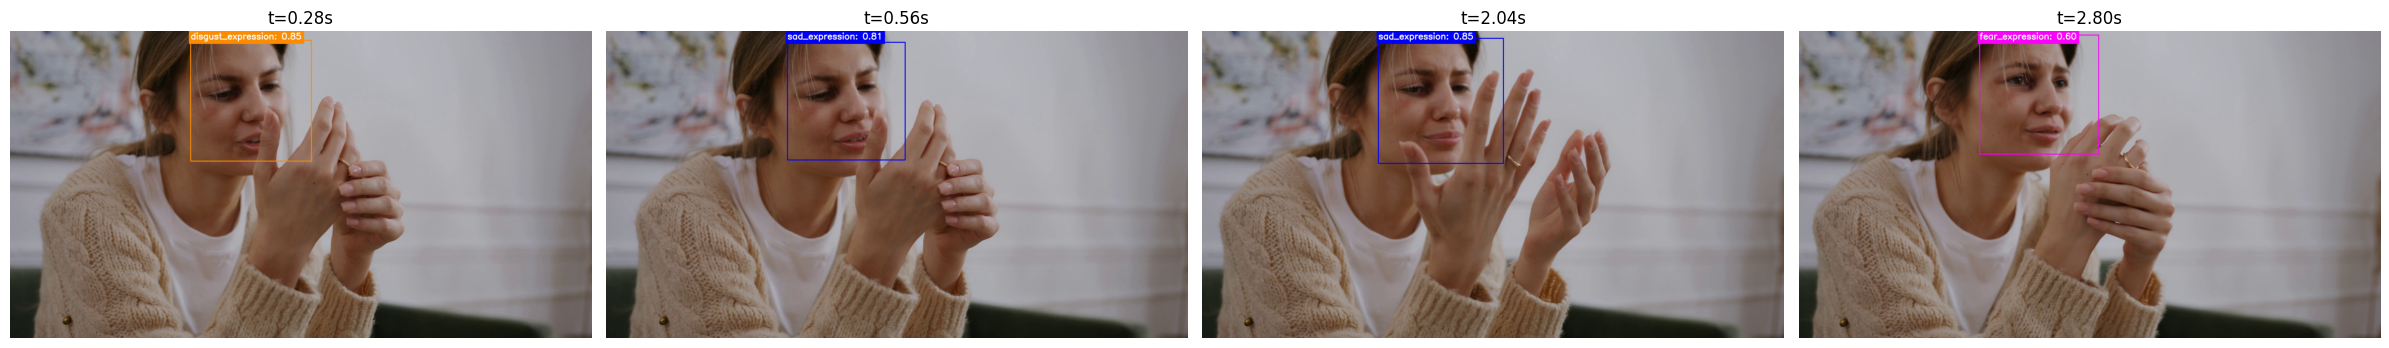

In [9]:
def read_frame_at_timestamp(video_path, timestamp_s):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return None
    try:
        capture.set(cv2.CAP_PROP_POS_MSEC, float(timestamp_s) * 1000.0)
        ok, frame = capture.read()
        if not ok:
            return None
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    finally:
        capture.release()


if 'RUN_RESULTS' not in globals() or not RUN_RESULTS:
    print('Execute primeiro a célula de processamento em lote.')
else:
    completed_results = [
        result
        for result in RUN_RESULTS
        if result.get('status') == 'completed' and result.get('annotated_video_path')
    ]

    if not completed_results:
        print('Nenhum vídeo concluído com artefatos disponíveis para preview.')
    else:
        first_result = completed_results[0]
        first_payload = first_result['payload']
        percentages = first_payload.get('percentages', {})
        segments = sorted(
            first_payload.get('segments', []),
            key=lambda item: (item.get('start_s', 0.0), item.get('end_s', 0.0)),
        )

        display(Markdown('\n'.join([
            '### Primeiro resultado desta execução',
            f"- video_id: `{first_result['video_id']}`",
            f"- vídeo anotado: `{first_result['annotated_video_path']}`",
            f"- json: `{first_result['json_path']}`",
        ])))

        percentage_rows = [
            {'label': label, 'percentual': percentage}
            for label, percentage in sorted(percentages.items(), key=lambda item: item[1], reverse=True)
        ]
        if percentage_rows:
            display(Markdown('### Percentuais por emoção'))
            display(pd.DataFrame(percentage_rows))

        segment_rows = [
            {'label': segment['label'], 'start_s': segment['start_s'], 'end_s': segment['end_s']}
            for segment in segments
        ]
        if segment_rows:
            display(Markdown('### Segmentos por tempo'))
            display(pd.DataFrame(segment_rows))

        display(Markdown('### JSON formatado'))
        display(Markdown(f"```json\n{json.dumps(first_payload, ensure_ascii=False, indent=2)}\n```"))

        timestamps = [segment['start_s'] for segment in segments[:4]]
        if not timestamps:
            timestamps = [0.0]

        frames = []
        for timestamp_s in timestamps:
            frame_rgb = read_frame_at_timestamp(first_result['annotated_video_path'], timestamp_s)
            if frame_rgb is not None:
                frames.append((timestamp_s, frame_rgb))

        if not frames:
            print('Não foi possível carregar frames de preview do vídeo anotado.')
        else:
            fig, axes = plt.subplots(1, len(frames), figsize=(6 * len(frames), 4))
            if len(frames) == 1:
                axes = [axes]

            for axis, (timestamp_s, frame_rgb) in zip(axes, frames):
                axis.imshow(frame_rgb)
                axis.set_title(f't={timestamp_s:.2f}s')
                axis.axis('off')

            plt.tight_layout()
            plt.show()
